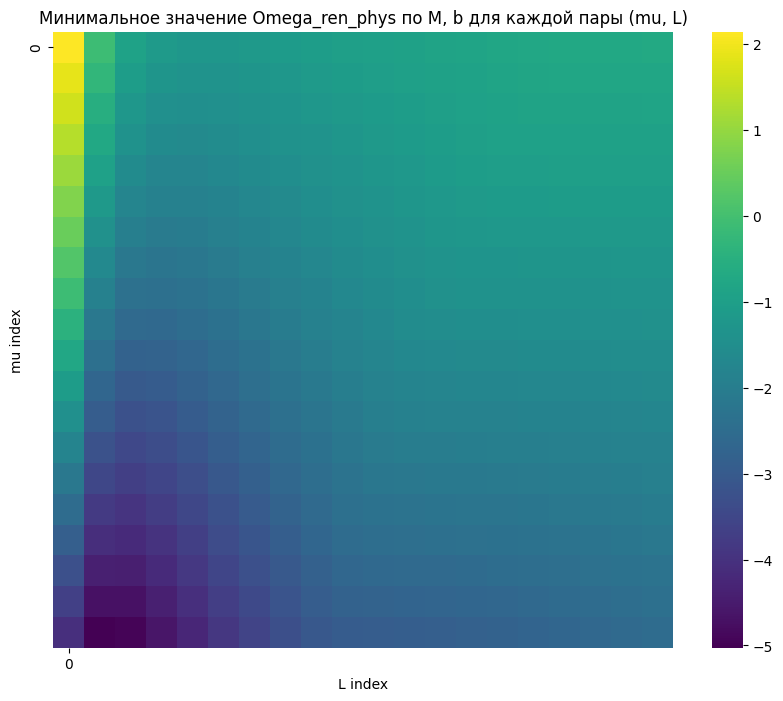

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Параметры сетки (должны совпадать с main.cpp)
MU_SPLIT = 20
L_SPLIT = 20
B_SPLIT = 21
M_SPLIT = 20

# Загрузка данных
filename = "Omega_ren_phys_cpp.txt"
assert os.path.exists(filename), f"Файл {filename} не найден!"
with open(filename, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

# Преобразование данных в массив
data = np.zeros((MU_SPLIT, L_SPLIT, B_SPLIT, M_SPLIT))
idx = 0
for mu_ind in range(MU_SPLIT):
    for L_ind in range(L_SPLIT):
        for b_ind in range(B_SPLIT):
            values = list(map(float, lines[idx].split()))
            data[mu_ind, L_ind, b_ind, :] = values
            idx += 1

# Поиск минимума по M и b для каждой пары (mu, L)
min_Omega = np.zeros((MU_SPLIT, L_SPLIT))
for mu_ind in range(MU_SPLIT):
    for L_ind in range(L_SPLIT):
        min_Omega[mu_ind, L_ind] = np.min(data[mu_ind, L_ind, :, :])

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(min_Omega, cmap='viridis', xticklabels=20, yticklabels=20)
plt.xlabel('L index')
plt.ylabel('mu index')
plt.title('Минимальное значение Omega_ren_phys по M, b для каждой пары (mu, L)')
plt.show()